<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Week_8_Assignment_Inferential_Statistics_and_Decision_Making_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Overview

You will complete ONE of the three scenarios below. Each scenario follows the same analysis structure but uses different datasets. Choose the scenario that best fits your field of study.

* **Time Estimate:** 3-4 hours
* **Tool:** Jupyter Notebook with Python
* **Key Libraries:** pandas, numpy, scipy, statsmodels, matplotlib, seaborn

**Choose Your Scenario:**

**Option A:** E-Commerce (Business)
  * File: business_conversion_data.csv
  * Focus: Does premium onboarding increase satisfaction and spending?


**Option B:** Healthcare Administration
  * File: healthcare_recovery.csv
  * Focus: Does telehealth improve satisfaction and reduce costs?


**Option C:** Public Administration
  * File: employment_program.csv
  * Focus: Does vocational training increase confidence and income?

# BUSINESS MAJORS

What You're Getting:

1. Dataset: business_conversion_data.csv
  * 300 customers (150 Control + 150 Treatment)
  * Realistic data with statistical differences built in
  * Variables: Customer_ID, Group, Satisfaction_Score (1-10), Monthly_Spend (dollars)


**Inferential Statistics & Decision-Making with Python**

## 📊 BUSINESS SCENARIO

**Optimizing E-Commerce Conversions: Premium Support vs. Standard Self-Service**


You are a Business Analyst for "**TechFlow**," a Software-as-a-Service (SaaS) company. The Marketing Director recently launched a "**Premium Onboarding**" pilot program (Treatment), where new users receive a 1-on-1 video call with a consultant. The Control Group receives the standard automated email welcome series.

🎯 **KEY BUSINESS QUESTION:**

  * Considering the cost of hiring consultants for 1-on-1 calls (approximately $50 per customer), does the increase in Monthly Spend justify the program's expansion to all new customers?

📁 **Dataset Information**
  * File: *business_conversion_data.csv*
  * Total Customers: 300 (150 Control + 150 Treatment)

## ✅ 7 ASSIGNMENT TASKS

* Complete ALL tasks below in a Jupyter Notebook.
* Each task should be clearly labeled and include both code and written interpretations.

**📦 FINAL SUBMISSION CHECKLIST**

1. ☐    Task 1: Data loaded with exploratory analysis (10 points)
2. ☐    Task 2: Summary statistics by group with interpretation (15 points)
3. ☐    Task 3: T-test results with interpretation (15 points)
4. ☐    Task 4: 95% confidence intervals with interpretation (15 points)
5. ☐    Task 5: Regression analysis with interpretation (20 points)
6. ☐    Task 6: Two visualizations with interpretations (15 points)
7. ☐    Task 7: Business recommendation memo (10 points)
8. ☐    All code cells run successfully without errors

## Task 1: Load and Explore the Data

**What to do:**

* Import necessary libraries (pandas, numpy, scipy, statsmodels, matplotlib, seaborn)
* Load business_conversion_data_csv into a pandas DataFrame
* Display the first 10 rows
* Check data types and look for missing values using df.info()
* Display basic descriptive statistics using describe()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_conversion_data.csv')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         300 non-null    int64  
 1   Group               300 non-null    object 
 2   Satisfaction_Score  300 non-null    float64
 3   Monthly_Spend       300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB
None
       Customer_ID  Satisfaction_Score  Monthly_Spend
count   300.000000          300.000000     300.000000
mean    150.500000            7.085667     173.241467
std      86.746758            1.695250      42.096099
min       1.000000            1.800000      52.410000
25%      75.750000            6.000000     144.492500
50%     150.500000            7.100000     174.320000
75%     225.250000            8.400000     204.805000
max     300.000000           10.000000     273.020000


## Task 2: Calculate Summary Statistics by Group

**What to do:**

1. Group Data by Control vs. Treatment
2. Calculate mean and standard deviation for Satisfaction_Score and Monthly_Spend for each group
3. Present results in a clear, formatted Summary Statistics table

In [16]:
summary_stats = df.groupby('Group').agg({'Satisfaction_Score':['mean', 'std'], 'Monthly_Spend':['mean', 'std']}).round(2)
print(summary_stats)

          Satisfaction_Score       Monthly_Spend       
                        mean   std          mean    std
Group                                                  
Control                 6.35  1.67        146.51  33.81
Treatment               7.82  1.37        199.97  31.22


## Task 3: Two-Sample T-Test for Satisfaction Scores

**What to do:**

1. Conduct an independent two-sample t-test comparing Satisfaction_Score between groups
2. Report t-statistic and p-value
3. Determine if there is a statistically significant difference (p <0.05)

In [18]:
control_sat = df[df['Group'] == 'Control']['Satisfaction_Score']
treatment_sat = df[df['Group'] == 'Treatment']['Satisfaction_Score']
t_stat, p_value = stats.ttest_ind(control_sat, treatment_sat)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
  print("Result: SIGNIFICANT")
else:
  print("Result: NOT SIGNIFICANT")

T-statistic: -8.3788
P-value: 0.0000
Result: SIGNIFICANT


## Task 4: Construct 95% Confidence Intervals

**What to do:**

1. Calculate 95% confidence interval for mean Monthly_Spend in BOTH groups
2. Report lower bound, mean, and upper bound for each group
3. Interpret what these intervals tell us about the difference between groups

In [19]:
from scipy.stats import t as t_dist
def confidence_interval_95(data):
  n = len(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  margin = std_err * t_dist.ppf(0.975, n-1)
  return mean, mean - margin, mean + margin

control_spend = df[df['Group'] == 'Control']['Monthly_Spend']
treatment_spend = df[df['Group'] == 'Treatment']['Monthly_Spend']
mean_c, lower_c, upper_c = confidence_interval_95(control_spend)
mean_t, lower_t, upper_t = confidence_interval_95(treatment_spend)
print(f"Control: ${mean_c:.2f} [${lower_c:.2f}, ${upper_c:.2f}]")
print(f"Treatment: ${mean_t:.2f} [${lower_t:.2f}, ${upper_t:.2f}]")

Control: $146.51 [$141.06, $151.97]
Treatment: $199.97 [$194.93, $205.01]


## Task 5: Regression Analysis

**What to do:**

1. Use statsmodels to run linear regression
2. Dependent variable: Monthly_Spend
3. Independent variables: Satisfaction_Score AND Group (Treatment = 1, Control = 0)
3. Report coefficients, p-values, and R-squared


In [20]:
df['Group_Treatment'] = (df['Group'] == 'Treatment').astype(int)
X = df[['Satisfaction_Score', 'Group_Treatment']]
y = df['Monthly_Spend']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:          Monthly_Spend   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     309.2
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           2.53e-73
Time:                        06:31:25   Log-Likelihood:                -1378.3
No. Observations:                 300   AIC:                             2763.
Df Residuals:                     297   BIC:                             2774.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 55.3014      6

## Task 6: Data Visualizations

**What to do:**

**Create TWO visualizations for Satisfaction_Score:**

1. Overlapping Histogram comparing Control vs. Treatment
2. Side-by-Side Box plots comparing Control vs. Treatment
3. Write brief interpretations for each visualization

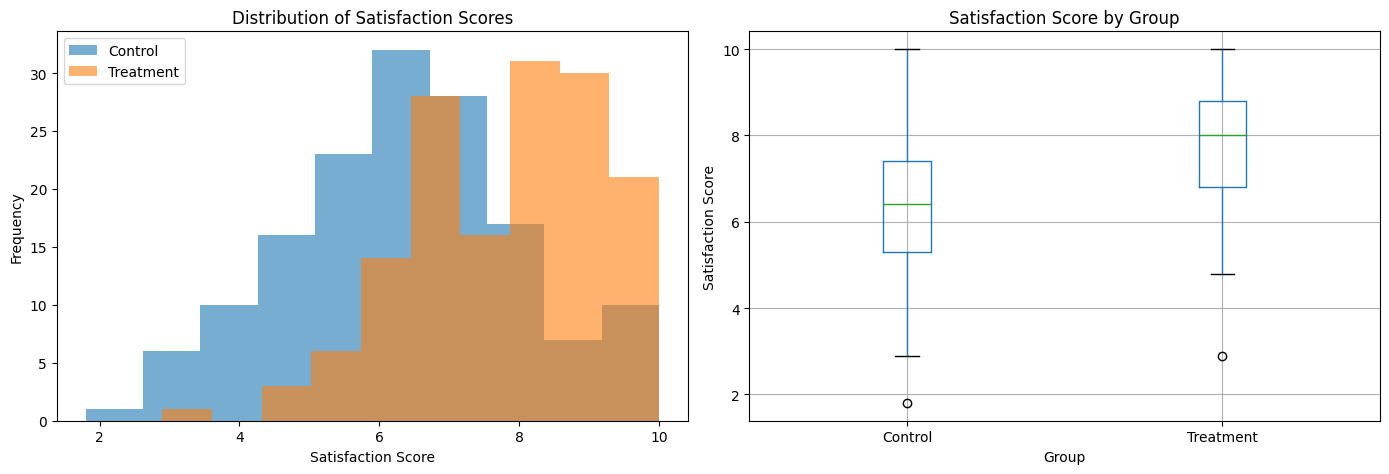

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ---- Histogram ----
ax1 = plt.subplot(1, 2, 1)
ax1.hist(control_sat, bins=10, alpha=0.6, label='Control')
ax1.hist(treatment_sat, bins=10, alpha=0.6, label='Treatment')
ax1.set_xlabel('Satisfaction Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Satisfaction Scores')
ax1.legend()

# ---- Box Plot ----
ax2 = plt.subplot(1, 2, 2)
df.boxplot(column='Satisfaction_Score', by='Group', ax=ax2)
ax2.set_xlabel('Group')
ax2.set_ylabel('Satisfaction Score')
ax2.set_title('Satisfaction Score by Group')

plt.suptitle('')  # Remove automatic pandas title
plt.tight_layout()
plt.show()

## Task 7: Business Recommendation Memo

**What to do:**

1. Synthesize ALL findings from Tasks 1-6
2. Consider the cost-benefit: Program costs $50 per customer
3. Make a clear YES/NO recommendation on program expansion
4. Support recommendation with specific statistics from your analysis

** See Question 7 for details on content and structure

# Healthcare Administration Scenario


**Context**

You are a **Hospital Administrator** at a major medical center. Your hospital recently piloted a **Telehealth Monitoring App** for patients recovering from minor surgeries (such as laparoscopic procedures, hernia repairs, and minor orthopedic surgeries).

**Control Group (Traditional):** Patients receive standard in-person follow-up appointments at the clinic

**Treatment Group (Innovation):** Patients use the Telehealth Monitoring App that allows them to:

1. Report symptoms daily via smartphone
2. Upload photos of surgical sites
3. Receive real-time feedback from nurses
4. Schedule virtual check-ins instead of in-person visits

KEY BUSINESS QUESTIONS:

1. Does the Telehealth App significantly improve patient satisfaction scores?
2. Does the app reduce recovery costs?
3. Is there a relationship between patient satisfaction and recovery costs?
4. Should the hospital invest in expanding this program hospital-wide?

🏥 What You're Getting:

1. Dataset: healthcare_recovery.csv


* 300 patients (150 Control + 150 Treatment)
* Realistic healthcare data with clinically meaningful differences
* Variables: Patient_ID, Group, Satisfaction_Score (1-10), Recovery_Cost (dollars)
    

**Important Note:** Recovery_Cost includes: follow-up appointment costs, additional treatment for complications, emergency room visits, readmission costs (if applicable), and medications for complications.

**✅ 7 ASSIGNMENT TASKS**


Complete ALL tasks below in a Jupyter Notebook.
Each task should be clearly labeled and include both code and written interpretations.

**📦 FINAL SUBMISSION CHECKLIST**

1. Task 1: Data loaded with exploratory analysis (10 points)
2. Task 2: Summary statistics by group with interpretation (15 points)
3. Task 3: T-test results with interpretation (15 points)
4. Task 4: 95% confidence intervals with interpretation (15 points)
5. Task 5: Regression analysis with interpretation (20 points)
6. Task 6: Two visualizations with interpretations (15 points)
7. Task 7: Business recommendation memo (10 points)
8. All code cells run successfully without errors

## Task 1: Load and Explore the Data

What to do:

- Import necessary libraries (pandas, numpy, scipy, statsmodels, matplotlib, seaborn)

- Load healthcare _recovery_csv into a pandas DataFrame

- Display the first 10 rows

- Check data types and look for missing values using df.info()

- Display basic descriptive statistics using describe()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/healthcare_recovery.csv')
display(df.head(10))
display(df.info())
display(df.describe())

,Patient_ID,Group,Satisfaction_Score,Recovery_Cost
0,263,Treatment,8.2,465.81
1,115,Control,8.8,1124.13
2,166,Treatment,7.2,821.27
3,279,Treatment,7.3,1194.54
4,294,Treatment,7.3,1138.10
5,170,Treatment,8.0,865.16
6,12,Control,7.0,1276.60
7,236,Treatment,7.8,1100.91
8,241,Treatment,8.8,465.92
9,207,Treatment,8.3,547.25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          300 non-null    int64  
 1   Group               300 non-null    object 
 2   Satisfaction_Score  300 non-null    float64
 3   Recovery_Cost       300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB


None

,Patient_ID,Satisfaction_Score,Recovery_Cost
count,300.000000,300.000000,300.000000
mean,150.500000,7.728333,934.574000
std,86.746758,1.510885,308.981021
min,1.000000,2.700000,300.000000
25%,75.750000,6.700000,703.835000
50%,150.500000,7.900000,910.540000
75%,225.250000,8.800000,1140.377500
max,300.000000,10.000000,2009.700000


## Task 2: Calculate Summary Statistics by Group

What to do:

1. Group Data by Control vs. Treatment
2. Calculate mean and standard deviation for Satisfaction_Score and Recovery_Cost for each group
3. Present results in a clear, formatted Summary Statistics table

In [14]:
summary_stats = df.groupby('Group').agg({'Satisfaction_Score':['mean', 'std'], 'Recovery_Cost':['mean', 'std']}).round(2)
print(summary_stats)



          Satisfaction_Score       Recovery_Cost        
                        mean   std          mean     std
Group                                                   
Control                 7.26  1.68       1112.86  272.86
Treatment               8.20  1.14        756.29  230.50


## Task 3: Two-Sample T-Test for Satisfaction Scores


What to do:

1. Conduct an independent two-sample t-test comparing Satisfaction_Score between groups
2. Report t-statistic and p-value
3. Determine if there is a statistically significant difference (p <0.05)

In [7]:
control_sat = df[df['Group'] == 'Control']['Satisfaction_Score']
treatment_sat = df[df['Group'] == 'Treatment']['Satisfaction_Score']
t_stat, p_value = stats.ttest_ind(control_sat, treatment_sat)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
  print("Result: SIGNIFICANT")
else:
    print("Result: NOT SIGNIFICANT")

T-statistic: -5.6830
P-value: 0.0000
Result: SIGNIFICANT


## Task 4: Construct 95% Confidence Intervals

What to do:

1. Calculate 95% confidence interval for mean Monthly_Spend in BOTH groups
2. Report lower bound, mean, and upper bound for each group
3. Interpret what these intervals tell us about the difference between groups

In [11]:
from scipy.stats import t as t_dist
def confidence_interval_95(data):
  n = len(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  margin = std_err * t_dist.ppf(0.975, n-1)
  return mean, mean - margin, mean + margin

control_cost = df[df['Group'] == 'Control']['Recovery_Cost']
treatment_cost = df[df['Group'] == 'Treatment']['Recovery_Cost']
mean_c, lower_c, upper_c = confidence_interval_95(control_cost)
mean_t, lower_t, upper_t = confidence_interval_95(treatment_cost)
print(f"Control: ${mean_c:.2f} [${lower_c:.2f}, ${upper_c:.2f}]")
print(f"Treatment: ${mean_t:.2f} [${lower_t:.2f}, ${upper_t:.2f}]")

Control: $1112.86 [$1068.84, $1156.88]
Treatment: $756.29 [$719.10, $793.48]


## Task 5: Regression Analysis

What to do:

1. Use statsmodels to run linear regression
2. Dependent variable: Monthly_Spend
3. Independent variables: Satisfaction_Score AND Group (Treatment = 1, Control = 0)
4. Report coefficients, p-values, and R-squared

In [10]:
df['Group_Treatment'] = (df['Group'] == 'Treatment').astype(int)
X = df[['Satisfaction_Score', 'Group_Treatment']]
y = df['Recovery_Cost']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Recovery_Cost   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     337.4
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           3.55e-77
Time:                        05:36:48   Log-Likelihood:                -1967.4
No. Observations:                 300   AIC:                             3941.
Df Residuals:                     297   BIC:                             3952.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2050.6949     52

## Task 6: Data Visualizations

What to do:

Create TWO visualizations for Satisfaction_Score:

* Overlapping Histogram comparing Control vs. Treatment
* Side-by-Side Box plots comparing Control vs. Treatment
* Write brief interpretations for each visualization

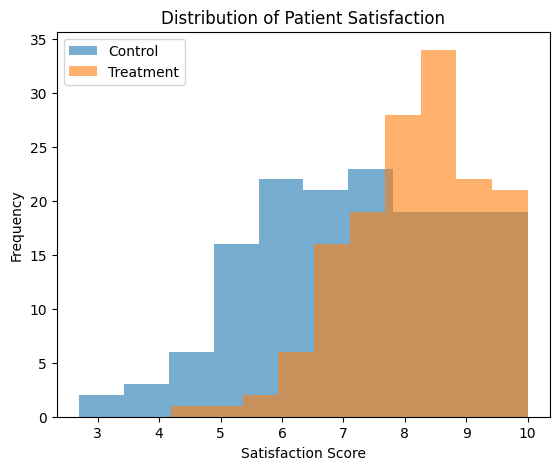

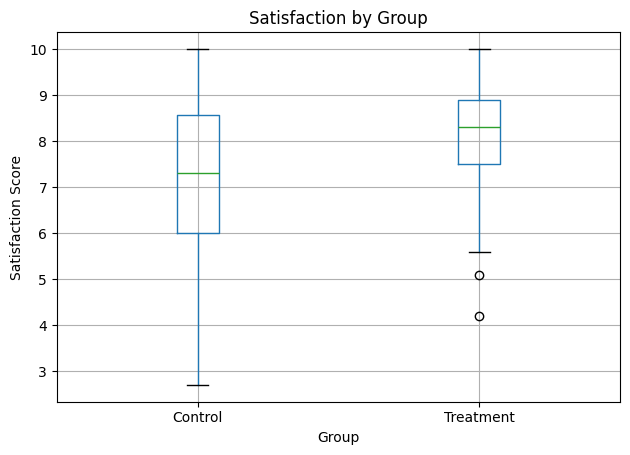

In [12]:
plt.figure(figsize=(14, 5)) # Histogram
plt.subplot(1, 2, 1)
plt.hist(control_sat, alpha=0.6, label='Control', bins=10)
plt.hist(treatment_sat, alpha=0.6, label='Treatment', bins=10)
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.title('Distribution of Patient Satisfaction')
plt.legend() # Box plot plt.subplot(1, 2, 2)

df.boxplot(column='Satisfaction_Score', by='Group')
plt.xlabel('Group')
plt.ylabel('Satisfaction Score')
plt.title('Satisfaction by Group')
plt.suptitle('')
plt.tight_layout()
plt.show()

# PUBLIC ADMINISTRATION SCENARIO

**Context**

You work for the Department of Labor in a mid-sized city. The city recently launched a "**Fast-Track Vocational Training**" program as a pilot initiative to help unemployed and underemployed residents gain marketable skills and achieve a "**Self-Sufficiency Wage**" - an income level that allows individuals to meet basic needs without public assistance.

**Control Group (Standard Assistance):** Participants receive traditional job search assistance including:

  1. Resume writing workshops
  2. Job fair access
  3. Online job board resources
  4. Basic interview coaching


**Treatment Group (Vocational Training):** Participants receive an intensive 12-week program including:

  1. Industry-specific skills training (healthcare, IT, skilled trades)
  2. Professional certification preparation
  3. Paid internship placement
  4. Job placement assistance with employer partners
  5. Career mentorship

## KEY POLICY QUESTIONS:

1. Does the Fast-Track Vocational Training program significantly improve participants' confidence in finding employment?
2. Does the program lead to higher monthly incomes (closer to self-sufficiency)?
3. Is there a relationship between job-market confidence and actual earnings?
4. Should the city council increase funding to expand the Fast-Track program?


## Dataset Information
**File:** employment_program.csv

**Total Participants:** 300 (150 Control + 150 Treatment)

**Time Period:** 12-month pilot program evaluation

**Note on Self-Sufficiency Wage:** The city defines the self-sufficiency wage as approximately $3,200/month ($38,400/year) for a single adult. This is the income needed to cover basic needs without public assistance.



## Instructions:
  1. Follow the same instructions as business majors but use the employment _program csv.
  2. Your Python code and questions will be different from Business majors
  3. Key Difference in deliverables have been listed in the submission  dropbox area at the bottom of the page

  **Python Codes Specific for Public Administration Project Tasks**

## Task 1: Load and Explore the Data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/employment_program.csv')
print(df.head(10))
print(df.info())
print(df.describe())

   Participant_ID      Group  Confidence_Score  Monthly_Income
0             201  Treatment               8.3         3443.59
1             220  Treatment               5.7         3275.08
2             125    Control               8.1         2508.29
3              53    Control               3.5         2487.08
4              35    Control               8.3         3628.81
5             177  Treatment               7.5         3465.81
6               9    Control               5.1         2505.88
7               4    Control               6.9         2916.83
8             241  Treatment               8.2         3552.72
9             193  Treatment               7.7         3986.17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Participant_ID    300 non-null    int64  
 1   Group             300 non-null    object 
 2   Confidence

## Task 2: Calculate Summary Statistics by Group

In [26]:
summary_stats = df.groupby('Group').agg({ 'Confidence_Score': ['mean', 'std'], 'Monthly_Income': ['mean', 'std'] }).round(2)
print(summary_stats)

          Confidence_Score       Monthly_Income        
                      mean   std           mean     std
Group                                                  
Control               6.00  1.85        2851.66  491.86
Treatment             7.49  1.52        3569.09  432.78


## Task 3: Two-Sample T-Test for Confidence Scores

In [27]:
control_conf = df[df['Group'] == 'Control']['Confidence_Score']
treatment_conf = df[df['Group'] == 'Treatment']['Confidence_Score']
t_stat, p_value = stats.ttest_ind(control_conf, treatment_conf)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
  print("Result: SIGNIFICANT")
else:
  print("Result: NOT SIGNIFICANT")

T-statistic: -7.6034
P-value: 0.0000
Result: SIGNIFICANT


## Task 4: Construct 95% Confidence Intervals

In [28]:
from scipy.stats import t as t_dist
def confidence_interval_95(data):
  n = len(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  margin = std_err * t_dist.ppf(0.975, n-1)
  return mean, mean - margin, mean + margin

control_income = df[df['Group'] == 'Control']['Monthly_Income']
treatment_income = df[df['Group'] == 'Treatment']['Monthly_Income']
mean_c, lower_c, upper_c = confidence_interval_95(control_income)
mean_t, lower_t, upper_t = confidence_interval_95(treatment_income)
print(f"Control: ${mean_c:.2f} [${lower_c:.2f}, ${upper_c:.2f}]")
print(f"Treatment: ${mean_t:.2f} [${lower_t:.2f}, ${upper_t:.2f}]")

Control: $2851.66 [$2772.30, $2931.02]
Treatment: $3569.09 [$3499.27, $3638.92]


## Task 5: Regression Analysis

In [29]:
df['Group_Treatment'] = (df['Group'] == 'Treatment').astype(int)
X = df[['Confidence_Score', 'Group_Treatment']]
y = df['Monthly_Income']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Monthly_Income   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     251.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.26e-64
Time:                        06:57:18   Log-Likelihood:                -2188.4
No. Observations:                 300   AIC:                             4383.
Df Residuals:                     297   BIC:                             4394.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1804.5559     79.288  

**PUBLIC POLICY NOTE:** In this scenario, POSITIVE coefficients are GOOD - they mean the program increases income, which is the desired outcome for workforce development.

## Task 6: Data Visualizations

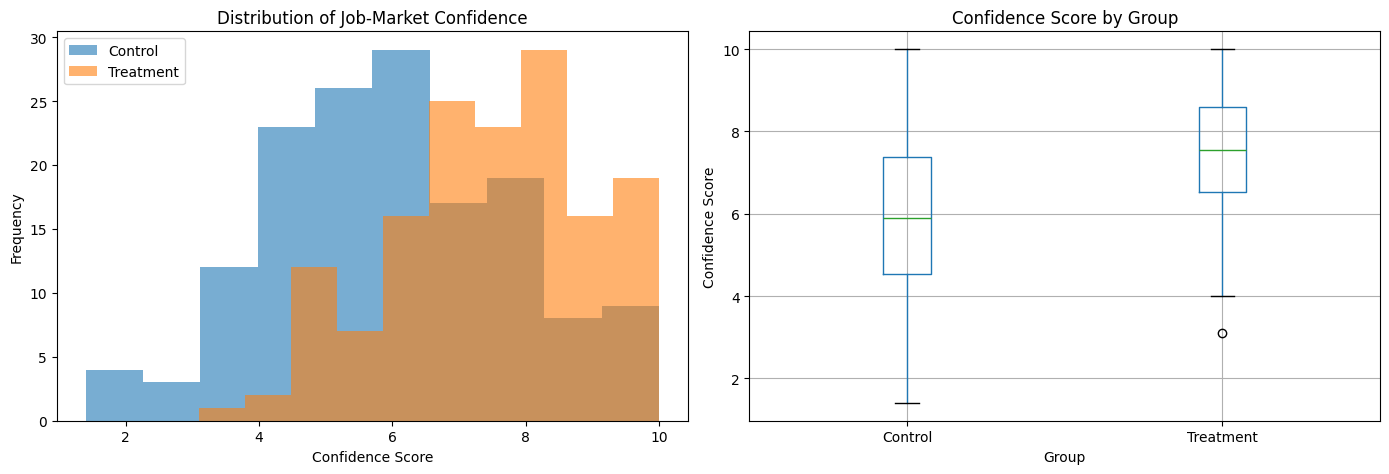

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ---- Histogram ----
ax1 = plt.subplot(1, 2, 1)
ax1.hist(control_conf, bins=10, alpha=0.6, label='Control')
ax1.hist(treatment_conf, bins=10, alpha=0.6, label='Treatment')
ax1.set_xlabel('Confidence Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Job-Market Confidence')
ax1.legend()

# ---- Box Plot ----
ax2 = plt.subplot(1, 2, 2)
df.boxplot(column='Confidence_Score', by='Group', ax=ax2)
ax2.set_xlabel('Group')
ax2.set_ylabel('Confidence Score')
ax2.set_title('Confidence Score by Group')

plt.suptitle('')  # Remove pandas automatic title
plt.tight_layout()
plt.show()